In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
train_df = pd.read_csv("/content/drive/MyDrive/2026-Summer/IDXExchange-Intern/cleaned_train.csv")
test_df = pd.read_csv("/content/drive/MyDrive/2026-Summer/IDXExchange-Intern/cleaned_test.csv")

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (129972, 39)
Test: (12024, 39)


In [4]:
# Remove Date and split columns

exclude_cols = ["ClosePrice", "CloseDate", "split"]

feature_cols = [
    col for col in train_df.columns
    if col not in exclude_cols
]

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

y_train = train_df["ClosePrice"]
y_test = test_df["ClosePrice"]

print("Feature count:", len(feature_cols))

Feature count: 36


In [5]:
# Check if all features are numerical or not (Because I already did encoding in the 02_preprocessing)

print(X_train.select_dtypes(exclude="number").columns)
print(X_train.isna().sum().sum())
print(X_test.isna().sum().sum())

Index([], dtype='object')
0
0


In [6]:
# Training the model with Linear Regression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [7]:
# Test

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"Test R²: {r2:.4f}")
print(f"Test RMSE: ${rmse:,.2f}")
print(f"Test MAE: ${mae:,.2f}")

Test R²: 0.4176
Test RMSE: $1,280,630.29
Test MAE: $440,380.44


In [8]:
baseline_results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "R2": [r2],
    "RMSE": [rmse],
    "MAE": [mae]
})

baseline_results.to_csv(
    "baseline_results.csv",
    index=False
)

baseline_results

,Model,R2,RMSE,MAE
0,Linear Regression,0.417585,1.280630e+06,440380.435535


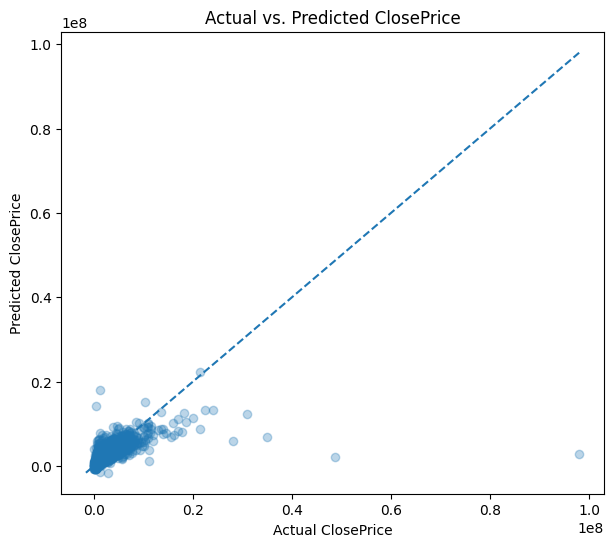

In [9]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.3)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs. Predicted ClosePrice")
plt.show()

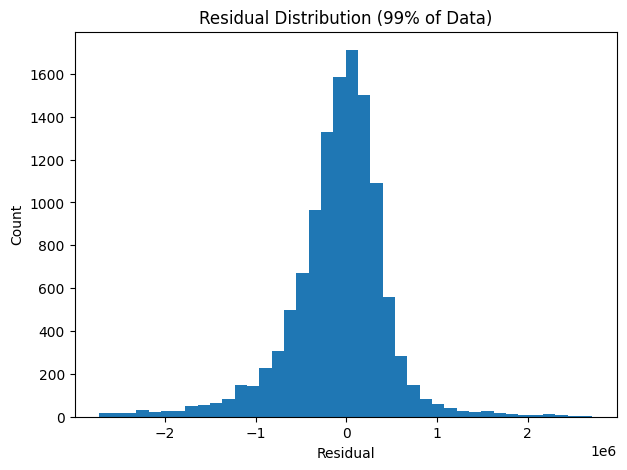

In [10]:
residual = y_test - y_pred

limit = residual.abs().quantile(0.99)

plt.figure(figsize=(7,5))
plt.hist(
    residual[residual.abs() <= limit],
    bins=40
)

plt.title("Residual Distribution (99% of Data)")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()

# Comparison

In [11]:
train_df["CloseDate"] = pd.to_datetime(train_df["CloseDate"])
test_df["CloseDate"] = pd.to_datetime(test_df["CloseDate"])

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

def evaluate_window(train_data, test_data, months):
    test_start = test_data["CloseDate"].min()
    train_start = test_start - pd.DateOffset(months=months)

    window_train = train_data[
        (train_data["CloseDate"] >= train_start) &
        (train_data["CloseDate"] < test_start)
    ].copy()

    exclude_cols = ["ClosePrice", "CloseDate", "split"]

    feature_cols = [
        col for col in window_train.columns
        if col not in exclude_cols
    ]

    X_train_window = window_train[feature_cols]
    y_train_window = window_train["ClosePrice"]

    X_test_window = test_data[feature_cols]
    y_test_window = test_data["ClosePrice"]

    model = LinearRegression()
    model.fit(X_train_window, y_train_window)

    y_pred_window = model.predict(X_test_window)

    return {
        "Training Window": f"{months} months",
        "Train Rows": len(window_train),
        "R2": r2_score(y_test_window, y_pred_window),
        "RMSE": np.sqrt(
            mean_squared_error(y_test_window, y_pred_window)
        ),
        "MAE": mean_absolute_error(
            y_test_window,
            y_pred_window
        )
    }

In [13]:
window_results = pd.DataFrame([
    evaluate_window(train_df, test_df, 6),
    evaluate_window(train_df, test_df, 9),
    evaluate_window(train_df, test_df, 12)
])

window_results

,Training Window,Train Rows,R2,RMSE,MAE
0,6 months,59442,0.424556,1.272943e+06,428122.342579
1,9 months,94381,0.433517,1.262993e+06,414171.784527
2,12 months,129972,0.417585,1.280630e+06,440380.435535


In [14]:
best_window = window_results.loc[
    window_results["R2"].idxmax()
]

best_window

,1
Training Window,9 months
Train Rows,94381
R2,0.433517
RMSE,1262992.734628
MAE,414171.784527


In [15]:
log_model = LinearRegression()

y_train_log = np.log1p(y_train)

log_model.fit(X_train, y_train_log)

y_pred_log = np.expm1(
    log_model.predict(X_test)
)

In [16]:
log_r2 = r2_score(y_test, y_pred_log)
log_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_log)
)
log_mae = mean_absolute_error(
    y_test,
    y_pred_log
)

log_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Log-Target Linear Regression"
    ],
    "R2": [r2, log_r2],
    "RMSE": [rmse, log_rmse],
    "MAE": [mae, log_mae]
})

log_results

,Model,R2,RMSE,MAE
0,Linear Regression,0.417585,1.280630e+06,440380.435535
1,Log-Target Linear Regression,-19.453773,7.589169e+06,464749.727758
